
## Lyapunov as metric FTLE

* As an independent validation metric, a finite-time sensitivity exponent was computed for the optimized initial conditions. The observed differences between the NIO high-tumor and low-tumor groups demonstrate that NIO successfully discovered distinct regions of the underlying dynamical system associated with different disease trajectories.



In [1]:


# ============================================================
# TUMOR FTLE / SENSITIVITY ANALYSIS
# Adapted from Lorenz Paper for IEEE BIBM
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde



In [2]:

# ============================================================
# CONFIGURATION
# ============================================================

MAX_FILE = "nio_tumor_max.csv"

random_flag = False

if random_flag:
    MIN_FILE    = "random_tumor_points.csv"
    name_output = "Random"
else:
    MIN_FILE    = "nio_tumor_min.csv"
    name_output = "Min"

HORIZON = 300


In [3]:

# ============================================================
# LOAD DATA
# ============================================================

max_df = pd.read_csv(MAX_FILE)
min_df = pd.read_csv(MIN_FILE)


In [4]:

time_col = [c for c in max_df.columns if "time" in c.lower()][0]


In [5]:

max_data = max_df[max_df[time_col] == HORIZON].copy()

if random_flag == False:
    min_data = min_df[min_df[time_col] == HORIZON].copy()
else:
    min_data = min_df.copy()


In [6]:



print("\nLoaded Data")
print("----------------------------")
print("Max-sensitive points :", len(max_data))
print("Min-sensitive points :", len(min_data))



Loaded Data
----------------------------
Max-sensitive points : 1000
Min-sensitive points : 1000


In [7]:


# =====================================================
# TUMOR–IMMUNE–CYTOKINE SYSTEM
# =====================================================

dt = 0.01

# tumor growth
a = 0.50
b = 0.01

# immune suppression
c = 0.02

# immune dynamics
d = 0.01
e = 0.10
f = 0.05

# cytokine dynamics
g = 0.05
h = 0.10



In [8]:

def tumor_step(x):

    T = x[0]
    I = x[1]
    C = x[2]

    dT = a*T*(1.0 - b*T) - c*T*I

    dI = d*T*I - e*I + f*C

    dC = g*T - h*C

    T = max(0.0, T + dt*dT)
    I = max(0.0, I + dt*dI)
    C = max(0.0, C + dt*dC)

    return np.array([T, I, C])


In [9]:


# =====================================================
# SIMULATOR
# =====================================================

def simulate_tumor(x0, steps=1000):

    x = np.array(x0, dtype=np.float64)

    traj = np.zeros((steps + 1, 3))

    traj[0] = x

    for i in range(steps):

        x = tumor_step(x)

        traj[i + 1] = x

    return traj


In [10]:

# =====================================================
# NIO DIVERGENCE SCORE
# SAME AS PAPER A
# =====================================================

def nio_divergence_score(
    x0,
    delta=1e-6,
    steps=1000
):

    x1 = np.array(x0)

    x2 = np.array(x0)

    x2[0] += delta

    traj1 = simulate_tumor(x1, steps)

    traj2 = simulate_tumor(x2, steps)

    separation = np.linalg.norm(
        traj2 - traj1,
        axis=1
    )

    score = np.sum(separation**2)

    return score


In [11]:


# =====================================================
# FINITE-TIME SENSITIVITY EXPONENT
# (same math as FTLE)
# =====================================================

def finite_time_lyapunov(
    x0,
    delta=1e-6,
    steps=900
):

    x1 = np.array(x0)

    x2 = np.array(x0)

    x2[0] += delta

    traj1 = simulate_tumor(x1, steps)

    traj2 = simulate_tumor(x2, steps)

    d0 = np.linalg.norm(
        traj2[0] - traj1[0]
    )

    dT = np.linalg.norm(
        traj2[-1] - traj1[-1]
    )

    dT = max(dT, 1e-12)

    lam = np.log(dT / d0) / (steps * dt)

    return lam




In [12]:




# =====================================================
# RANDOM BASELINE
# =====================================================

def generate_random_points(n=1000):

    pts = np.zeros((n,3))

    pts[:,0] = np.random.uniform(1,100,n)   # T0
    pts[:,1] = np.random.uniform(1,100,n)   # I0
    pts[:,2] = np.random.uniform(1,100,n)   # C0

    return pts


random_points = generate_random_points(1000)


In [13]:



# =====================================================
# EXTRACT INITIAL CONDITIONS
# =====================================================

max_data_np = max_data[
    ["T0","I0","C0"]
].to_numpy()

min_data_np = min_data[
    ["T0","I0","C0"]
].to_numpy()

high_points = max_data_np
low_points  = min_data_np


In [14]:



# =====================================================
# COMPUTE FTLE
# =====================================================

print("Computing sensitivity exponents...")

high_ftle = []
low_ftle  = []
rand_ftle = []

for p in high_points:

    high_ftle.append(
        finite_time_lyapunov(
            p,
            steps=HORIZON
        )
    )

for p in low_points:

    low_ftle.append(
        finite_time_lyapunov(
            p,
            steps=HORIZON
        )
    )
    
    



for p in random_points:

    rand_ftle.append(
        finite_time_lyapunov(
            p,
            steps=HORIZON
        )
    )

high_ftle = np.array(high_ftle)
low_ftle  = np.array(low_ftle)
rand_ftle = np.array(rand_ftle)


Computing sensitivity exponents...


In [15]:



# =====================================================
# RESULTS
# =====================================================

print("\n==============================")
print("FINITE-TIME SENSITIVITY")
print("==============================")

print(
    "NIO MAX  Mean:",
    np.mean(high_ftle)
)

print(
    "NIO MIN  Mean:",
    np.mean(low_ftle)
)

print(
    "Random   Mean:",
    np.mean(rand_ftle)
)

print()

print(
    "NIO MAX  Std:",
    np.std(high_ftle)
)


print(
    "NIO MIN  Std:",
    np.std(low_ftle)
)

print(
    "Random   Std:",
    np.std(rand_ftle)
)





FINITE-TIME SENSITIVITY
NIO MAX  Mean: -0.5418444511348912
NIO MIN  Mean: -0.2999130967606077
Random   Mean: -0.23607840617071135

NIO MAX  Std: 7.378713793301164e-05
NIO MIN  Std: 0.055111972338068624
Random   Std: 0.10080004573878194


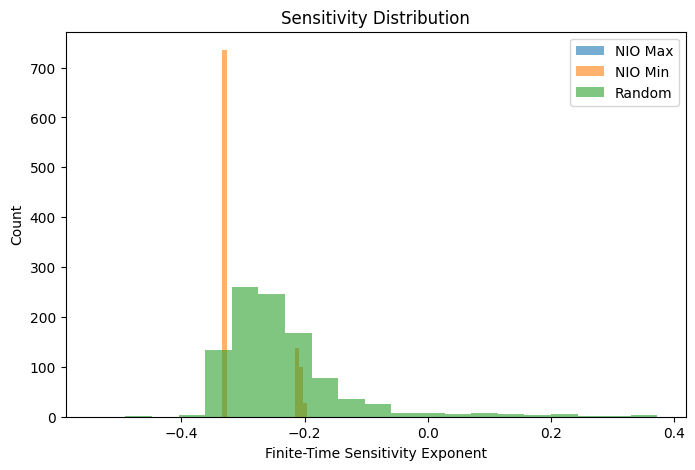

In [16]:



# =====================================================
# HISTOGRAM
# =====================================================

plt.figure(figsize=(8,5))

plt.hist(
    high_ftle,
    bins=20,
    alpha=0.6,
    label="NIO Max"
)

plt.hist(
    low_ftle,
    bins=20,
    alpha=0.6,
    label="NIO Min"
)

plt.hist(
    rand_ftle,
    bins=20,
    alpha=0.6,
    label="Random"
)



plt.xlabel("Finite-Time Sensitivity Exponent")
plt.ylabel("Count")

plt.title(
    "Sensitivity Distribution"
)

plt.legend()

plt.show()










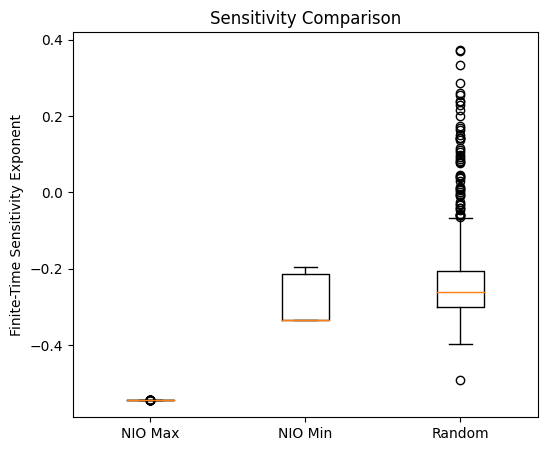

In [17]:


# =====================================================
# BOXPLOT
# =====================================================

plt.figure(figsize=(6,5))

plt.boxplot(
    [
        high_ftle,
        low_ftle,
        rand_ftle
    ],
    labels=[
        "NIO Max",
        "NIO Min",
        "Random"
    ]
)

plt.ylabel(
    "Finite-Time Sensitivity Exponent"
)

plt.title(
    "Sensitivity Comparison"
)

plt.show()




Computing NIO scores...

Correlation (NIO Score vs Sensitivity): 0.32752588895997314


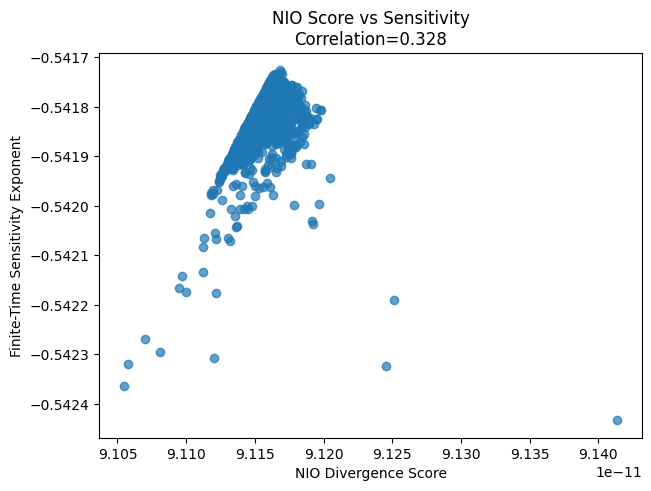

In [18]:



# =====================================================
# CORRELATION WITH NIO SCORE
# =====================================================

print("\nComputing NIO scores...")

high_scores = []

for p in high_points:

    high_scores.append(
        nio_divergence_score(
            p,
            steps=HORIZON
        )
    )

high_scores = np.array(high_scores)

corr = np.corrcoef(
    high_scores,
    high_ftle
)[0,1]

print()



print(
    "Correlation (NIO Score vs Sensitivity):",
    corr
)

plt.figure(figsize=(7,5))

plt.scatter(
    high_scores,
    high_ftle,
    alpha=0.7
)

plt.xlabel(
    "NIO Divergence Score"
)

plt.ylabel(
    "Finite-Time Sensitivity Exponent"
)

plt.title(
    f"NIO Score vs Sensitivity\nCorrelation={corr:.3f}"
)

plt.show()



In [19]:



# =====================================================
# MOST SENSITIVE INITIAL STATE
# =====================================================

idx = np.argmax(high_ftle)

print("\nMost Sensitive Tumor Initial State")

print(
    "Initial State (T0,I0,C0):",
    high_points[idx]
)

print(
    "Sensitivity Exponent:",
    high_ftle[idx]
)

print(
    "NIO Score:",
    high_scores[idx]
)



Most Sensitive Tumor Initial State
Initial State (T0,I0,C0): [94.348595   1.0089625  1.0045722]
Sensitivity Exponent: -0.5417259491500794
NIO Score: 9.116814386073397e-11


In [20]:




# =====================================================
# COMPARE NIO SCORES
# =====================================================

high_scores = []

for p in high_points:

    high_scores.append(
        nio_divergence_score(
            p,
            steps=HORIZON
        )
    )

high_scores = np.array(high_scores)

low_scores = []

for p in low_points:

    low_scores.append(
        nio_divergence_score(
            p,
            steps=HORIZON
        )
    )

low_scores = np.array(low_scores)

random_scores = []

for p in random_points:

    random_scores.append(
        nio_divergence_score(
            p,
            steps=HORIZON
        )
    )

random_scores = np.array(random_scores)

print()
print("NIO MAX Mean Score :", high_scores.mean())
print("NIO MIN Mean Score :", low_scores.mean())
print("Random  Mean Score :", random_scores.mean())



NIO MAX Mean Score : 9.1154619900969e-11
NIO MIN Mean Score : 7.426728822013878e-11
Random  Mean Score : 1.233225389703446e-10
